<a href="https://colab.research.google.com/github/Mashael-fs/IT326-Cardiovascular-Disease/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler


sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)


###Project Goal:

The primary goal of this project is to analyze cardiovascular health data using classification and clustering techniques. The classification task aims to classify patients based on the presence or absence of cardiovascular disease using their health and lifestyle characteristics. In addition, clustering techniques will be used to group patients with similar characteristics and identify meaningful patterns within the dataset. By applying these data mining techniques, the project aims to better understand the factors and patterns associated with cardiovascular disease.

###Dataset Source

The dataset used in this project was obtained from Kaggle and is titled “Cardiovascular Disease Dataset".
https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset

### Dataset Description
**Features**: Data types and numbers of the attributes.




In [ ]:
df = pd.read_csv("Raw_dataset.csv",sep=";")
print("Number of attributes:",df.shape[1])
print(df.dtypes)

Number of attributes: 13
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


**Number of Objects**: Based on the dataset provided, there are
70000 rows.


In [ ]:
print("Number of Rows:",df.shape[0])

Number of Rows: 70000


**Class Distribution:**
From our class label (cardiovascular disease) there are 35021 patients with no cardiovascular disease and 34979 patients with cardiovascular disease.

In [ ]:
print("Target Column (class attribute): cardio")

count_0 = df[df["cardio"] == 0].shape[0]
count_1 = df[df["cardio"] == 1].shape[0]

print(f"- Patients with NO cardiovascular disease (0): {count_0}")
print(f"- Patients WITH cardiovascular disease (1): {count_1}")

Target Column (class attribute): cardio
- Patients with NO cardiovascular disease (0): 35021
- Patients WITH cardiovascular disease (1): 34979


**Dataset Sample:**
Sample of the raw dataset.

In [ ]:

print("\n\033[1mDataset Sample (first 5 rows):\033[0m")
print(tabulate(df.head(), headers="keys", tablefmt="fancy_grid"))


Dataset Sample (first 5 rows):
╒════╤══════╤═══════╤══════════╤══════════╤══════════╤═════════╤═════════╤═══════════════╤════════╤═════════╤════════╤══════════╤══════════╕
│    │   id │   age │   gender │   height │   weight │   ap_hi │   ap_lo │   cholesterol │   gluc │   smoke │   alco │   active │   cardio │
╞════╪══════╪═══════╪══════════╪══════════╪══════════╪═════════╪═════════╪═══════════════╪════════╪═════════╪════════╪══════════╪══════════╡
│  0 │    0 │ 18393 │        2 │      168 │       62 │     110 │      80 │             1 │      1 │       0 │      0 │        1 │        0 │
├────┼──────┼───────┼──────────┼──────────┼──────────┼─────────┼─────────┼───────────────┼────────┼─────────┼────────┼──────────┼──────────┤
│  1 │    1 │ 20228 │        1 │      156 │       85 │     140 │      90 │             3 │      1 │       0 │      0 │        1 │        1 │
├────┼──────┼───────┼──────────┼──────────┼──────────┼─────────┼─────────┼───────────────┼────────┼─────────┼────────┼────

# **Phase** **2**:

## Data Analysis

### 1- Statistical Summaries


In [ ]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


The statistical summary provides an overview of the numerical attributes by showing the count, mean, standard deviation, minimum, quartiles, and maximum values. It also reveals some unusual values, especially in blood pressure, height, and weight, which may indicate noisy data or outliers that require further investigation and preprocessing.

### 2- Missing Values Analysis


In [ ]:
missing = df.isnull().sum()

print("Missing Values:")
print(missing)

print("\nTotal Missing Values: ", missing.sum())

Missing Values:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

Total Missing Values:  0


The missing values analysis shows the number of missing values in each attribute of the dataset. The results indicate that there are no missing values in any of the attributes, so no missing value handling technique is required.

## **Visualizations:**

### 3- Categorical Attribute Distributions - Bar Plots

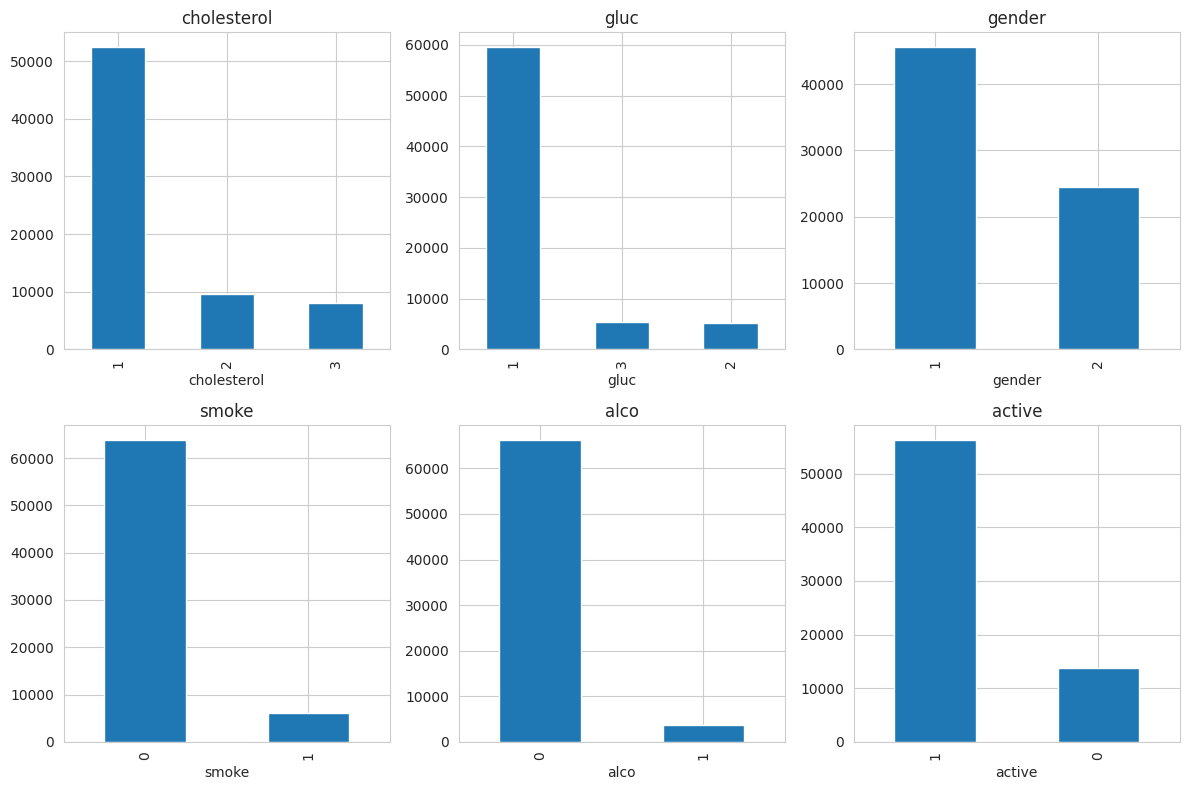

In [ ]:
cat_cols = ["cholesterol", "gluc", "gender", "smoke", "alco", "active"]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

The bar plots show the distribution of categorical variables such as smoking, alcohol use, activity, cholesterol, glucose, and gender. Most values are concentrated in one category, indicating imbalance in some variables. This shows that the data is already numerically encoded, so no major preprocessing is needed. However, class imbalance may need to be handled in later modeling steps

### 4- Numeric attribute distributions - Histograms

Histograms of `age`, `height`, `weight`, `ap_hi` (systolic BP) and `ap_lo` (diastolic BP).

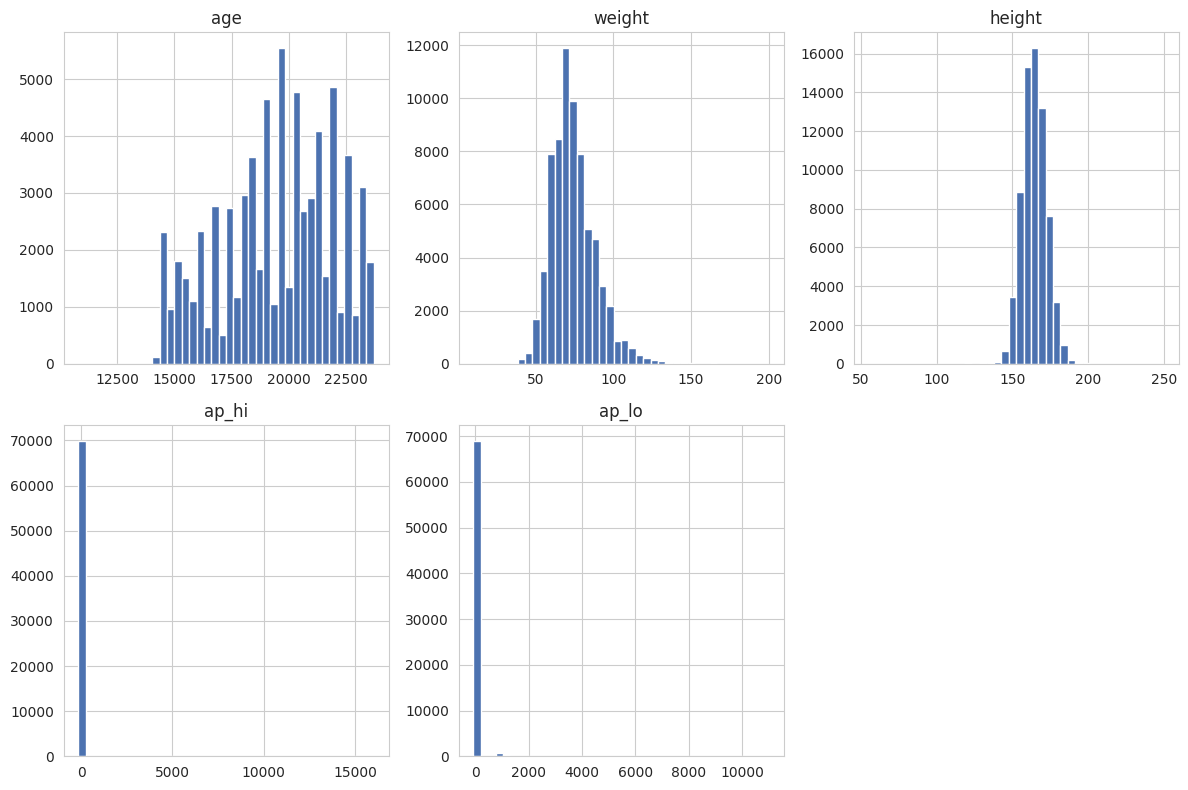

In [ ]:
numeric_cols = ["age", "weight", "height", "ap_hi", "ap_lo"]

df[numeric_cols].hist(bins=40, figsize=(12, 8), layout=(2, 3), color="#4C72B0")
plt.tight_layout()
plt.show()

These histograms illustrate the distributions of the numerical features, where ⁠age⁠ spans a broad range in days, ⁠weight⁠ and ⁠height⁠ show approximately normal distributions, and blood pressure features (⁠ap_hi⁠ and ⁠ap_lo⁠) are heavily compressed due to extreme outliers exceeding 10,000. This guided our preprocessing decisions specifically for these continuous attributes: the presence of unrealistic values indicated the need for noise removal to discard severe outliers, the wide age span justified applying discretisation to group ages into categorical intervals, and the differing numerical scales across the features confirmed the necessity of normalisation to standardize them onto a uniform scale.

###5- Box Plot

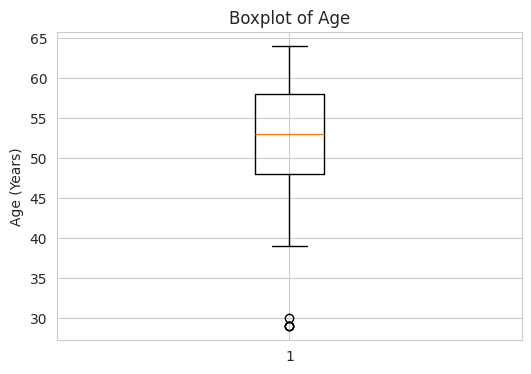

five number summary:
Min: 29
Q1: 48.0
Median: 53.0
Q3: 58.0
Max: 64


In [ ]:
age_in_years=(df["age"]/365).astype(int)
plt.figure(figsize=(6,4))
plt.boxplot(age_in_years)
plt.title("Boxplot of Age")
plt.ylabel("Age (Years)")
plt.show()
q1 = np.percentile(age_in_years, 25)
q2 = np.percentile(age_in_years, 50)
q3 = np.percentile(age_in_years, 75)
print("five number summary:")
print("Min:", np.min(age_in_years))
print("Q1:", q1)
print("Median:", q2)
print("Q3:", q3)
print("Max:", np.max(age_in_years))

Based on the displayed boxplot, the minimum value is 29 and the maximum value is 64. The lower whisker is at 39, and the upper whisker is at 64. The first quartile (Q1) is approximately 48, the third quartile (Q3) is approximately 58, and the median, represented by the orange line, is 53. Two outliers (29 and 30) are shown.


### Outlier







In [ ]:
Q1 = np.percentile(age_in_years, 25)
Q3 = np.percentile(age_in_years, 75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = set(age_in_years[(age_in_years < lower) | (age_in_years > upper)])
print("Outliers:",outliers)

Outliers: {29, 30}


The interquartile range (IQR) method was used to identify outliers in age: values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are considered outliers. Consequently, two values, 29 and 30, were detected.

### 6- Relationship Between Numeric Attributes - Scatter Plot

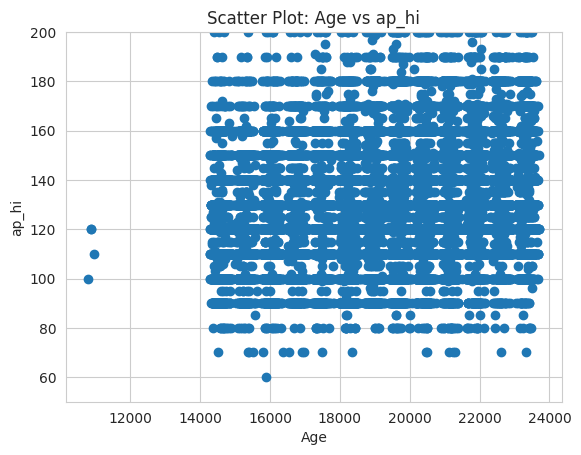

In [ ]:
plt.figure()
plt.scatter(df['age'], df['ap_hi'])
plt.title("Scatter Plot: Age vs ap_hi")
plt.xlabel("Age")
plt.ylabel("ap_hi")
plt.ylim(50, 200)
plt.show()


This scatter plot illustrates the relationship between ⁠Age⁠ (recorded in days) and systolic blood pressure (⁠ap_hi⁠), showing dense horizontal clustering due to rounded clinical measurements along with scattered extreme points. This information guided our preprocessing decisions specifically for these two attributes: the isolated outlying points highlighted the necessity of noise removal to eliminate erroneous measurements and outliers, the continuous, large scale of age values supported applying discretisation to categorize age into meaningful clinical brackets, and the significant discrepancy between the scales of the two axes (thousands vs. tens) confirmed the clear need for normalisation to bring both features onto a standardized, comparable scale.

###7- Class label distribution

`cardio` (0 = no cardiovascular disease, 1 = disease) is the target attribute.

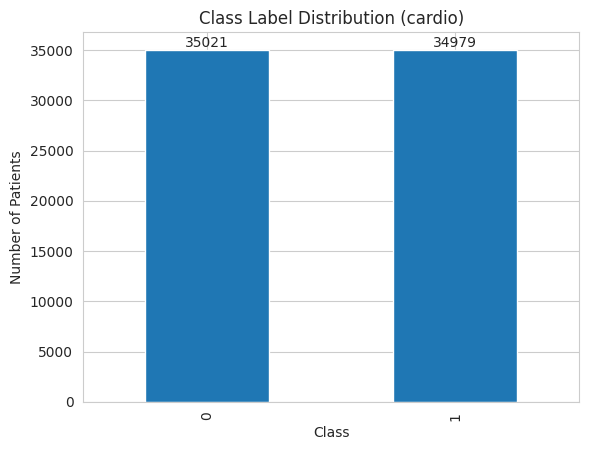

In [ ]:
plt.figure()
ax= df['cardio'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.title("Class Label Distribution (cardio)")
plt.xlabel("Class")
plt.ylabel("Number of Patients")
plt.show()

This bar plot illustrates the distribution of the target variable ⁠cardio⁠, showing 35,021 patients without cardiovascular disease and 34,979 with cardiovascular disease across 70,000 records, confirming an almost exact 50:50 distribution. This information demonstrates that the target variable is completely balanced, cleanly defined into binary classes, and free from erroneous entries, confirming that it is already in an ideal state and requires no preprocessing whatsoever.

# Data Preprocessing

###Raw Dataset

In [ ]:
print(df.head())
print(df.info())
print(df.describe())

   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4     0       0       0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4

The raw dataset represents the original data before applying the preprocessing techniques.

## **Data preprocessing techniques:**




### 1- Noise Removal

In [ ]:
numeric_cols = ["height", "weight", "ap_hi", "ap_lo"]

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Outliers removed. Dataset shape after cleaning:", df.shape)

Outliers removed. Dataset shape after cleaning: (62505, 13)


The Interquartile Range (IQR) method was applied to the continuous numerical features (⁠height⁠, ⁠weight⁠, ⁠ap_hi⁠, and ⁠ap_lo⁠). Upper and lower bounds were defined as Q3 + 1.5 IQR and Q1 - 1.5 IQR respectively, filtering out extreme physiological anomalies such as unrealistic blood pressure values and implausible body measurements.

Successfully eliminated noisy records and severe outliers, cleaning the dataset and reducing the total count from 70,000 to 62,505 valid records.

### 2- Discretization

In [ ]:
df['age_years'] = (df['age'] / 365).astype(int)

df['Age_Group'] = pd.cut(df['age_years'],
                         bins=3,
                         labels=['Young', 'Middle', 'Old'])

print("Age Group Column:")
print(tabulate(df[['age_years', 'Age_Group']].head().reset_index(drop=True),
      headers='keys',
      tablefmt='fancy_grid',
      stralign='center',
      numalign='center'))

Age Group Column:
╒════╤═════════════╤═════════════╕
│    │  age_years  │  Age_Group  │
╞════╪═════════════╪═════════════╡
│ 0  │     50      │   Middle    │
├────┼─────────────┼─────────────┤
│ 1  │     55      │     Old     │
├────┼─────────────┼─────────────┤
│ 2  │     51      │   Middle    │
├────┼─────────────┼─────────────┤
│ 3  │     48      │   Middle    │
├────┼─────────────┼─────────────┤
│ 4  │     60      │     Old     │
╘════╧═════════════╧═════════════╛


The age attribute (originally in days) was converted into years (⁠age_years = age / 365⁠) and then binned using equal-width interval discretization (⁠pd.cut⁠ with ⁠bins=3⁠) into three categorical age brackets: Young, Middle, and Old.

Simplified the age feature into meaningful clinical groups (⁠Age_Group⁠), enhancing feature interpretability and capturing non-linear age-group trends for pattern analysis.

### 3- Z-score Normalization

In [ ]:
continuous_cols = ["age", "height", "weight", "ap_hi", "ap_lo", "age_years"]

scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

print("First 5 rows after Normalization:")
df.head()

First 5 rows after Normalization:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,Age_Group
0,0,-0.447523,2,0.477189,-0.911080,-1.149069,-0.221405,1,1,0,0,1,0,-0.431208,Middle
1,1,0.298797,1,-1.116160,0.963105,0.950343,1.081815,3,1,0,0,1,1,0.310276,Old
2,2,-0.258808,1,0.078852,-0.748108,0.250539,-1.524624,3,1,0,0,0,1,-0.282911,Middle
3,3,-0.760693,2,0.609968,0.718646,1.650146,2.385035,1,1,0,0,1,1,-0.727801,Middle
5,8,0.984517,1,-1.780056,-0.503649,-0.449265,-0.221405,2,2,0,0,0,0,1.051760,Old


Applied ⁠StandardScaler⁠ to all continuous features (⁠age⁠, ⁠height⁠, ⁠weight⁠, ⁠ap_hi⁠, and ⁠ap_lo, age_years⁠) to scale their values so they have a mean of 0 and a standard deviation of 1.

Rescaled feature magnitude disparities without distorting underlying distributions. This ensures distance-based and gradient-based machine learning models will not be biased toward features with larger numerical ranges.

## **Data Set after we Preprocessed it:**


 ### Preprocessed Dataset

In [ ]:
preprocessed_df=df.copy()

print(preprocessed_df.head())
print(preprocessed_df.info())
print(preprocessed_df.describe())

   id       age  gender    height    weight     ap_hi     ap_lo  cholesterol  \
0   0 -0.447523       2  0.477189 -0.911080 -1.149069 -0.221405            1   
1   1  0.298797       1 -1.116160  0.963105  0.950343  1.081815            3   
2   2 -0.258808       1  0.078852 -0.748108  0.250539 -1.524624            3   
3   3 -0.760693       2  0.609968  0.718646  1.650146  2.385035            1   
5   8  0.984517       1 -1.780056 -0.503649 -0.449265 -0.221405            2   

   gluc  smoke  alco  active  cardio  age_years Age_Group  
0     1      0     0       1       0  -0.431208    Middle  
1     1      0     0       1       1   0.310276       Old  
2     1      0     0       0       1  -0.282911    Middle  
3     1      0     0       1       1  -0.727801    Middle  
5     2      0     0       0       0   1.051760       Old  
<class 'pandas.core.frame.DataFrame'>
Index: 62505 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------ 

The preprocessed dataset represents the data after applying the preprocessing techniques. Outliers were removed, age was discretized into three groups (Young, Middle, and Old), and normalization was applied to the numeric features. The target attribute (cardio) was kept unchanged with its original values (0 and 1).

In [ ]:
preprocessed_df.to_csv("/content/Preprocessed_dataset.csv", index=False)
print("Preprocessed dataset saved successfully.")
print("Final dataset shape:", preprocessed_df.shape)

Preprocessed dataset saved successfully.
Final dataset shape: (62505, 15)


The preprocessed dataset was saved as a CSV file named Preprocessed_dataset.csv. The code also displays the final shape of the dataset to show the number of rows and columns.

## **Overall Description:**

During the data preprocessing phase, several techniques were applied to improve the quality of the cardiovascular disease dataset and prepare it for the data mining tasks. The dataset was first analyzed and found to contain no missing values, so no missing value treatment was required. However, the statistical summaries and visualizations revealed unrealistic and extreme values, particularly in height, weight, systolic blood pressure (ap_hi), and diastolic blood pressure (ap_lo). Noise removal was therefore performed using the Interquartile Range (IQR) method, reducing the dataset from 70,000 to 62,505 records after removing severe outliers. Age, which was originally recorded in days, was converted into years and then discretized into three groups Young, Middle, and Old to make the attribute easier to interpret and analyze. In addition, Standard Score (Z-score) normalization was applied to the continuous numerical attributes to place them on a comparable scale with a mean of zero and a standard deviation of one, preventing attributes with larger numerical ranges from having excessive influence on distance based analysis. After completing these preprocessing steps, the resulting dataset was reviewed and saved separately as Preprocessed_dataset.csv, while the original raw dataset remained unchanged.



###